In [1]:
# 7-1-2026

In [33]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from scipy.stats import kendalltau, spearmanr

In [2]:
transfer_matrix = pd.read_csv("../transfer-matrix/rf_transfer_matrix.csv")
transfer_matrix.set_index("Unnamed: 0", inplace=True)
transfer_matrix.index.name = None
transfer_matrix.index = transfer_matrix.index.astype(int)
transfer_matrix.columns = transfer_matrix.columns.astype(int)
transfer_matrix

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,0.392727,0.291660,0.127238,0.058840,0.214817,0.084705,0.149056,0.182358,0.173877,0.026375,...,0.228505,0.243433,0.149609,0.275203,0.112525,-0.011557,0.116862,0.158796,0.025454,0.029928
1,0.142172,0.395760,0.030643,0.010376,0.180707,0.064432,0.056092,0.128808,0.097788,0.039590,...,0.167477,0.032806,0.029704,0.193033,0.055264,0.066550,0.108203,0.199762,0.023240,-0.037710
2,0.196600,0.214445,0.368173,0.023968,0.207323,0.140139,0.172990,0.231019,0.156741,0.057226,...,0.197402,0.223793,0.121457,0.248807,0.134485,0.053503,-0.005610,0.253965,0.031899,0.059566
4,0.235489,0.227173,0.127394,0.410382,0.215954,0.186207,0.125068,0.196603,0.165264,0.034514,...,0.178055,0.245668,0.147579,0.284360,0.217076,-0.003941,0.037643,0.306750,0.137154,0.020968
5,0.190803,0.206530,0.097887,0.087230,0.464604,0.144950,0.159361,0.204884,0.264641,0.104493,...,0.197195,0.232923,0.117228,0.292623,0.170687,-0.020694,0.115293,0.297271,0.067951,0.051770
6,0.178282,0.238235,0.034447,0.220869,0.191487,0.317381,0.118250,0.163631,0.119401,0.021430,...,0.202794,0.247076,0.125801,0.255555,0.201974,-0.068777,0.099243,0.321076,0.102840,-0.017236
7,0.113396,0.054282,0.061550,0.069370,0.044484,0.109329,0.329688,0.092023,0.159883,0.051387,...,0.184071,0.179713,0.142222,0.192045,0.209176,0.035736,0.042035,0.159817,0.008022,0.022467
8,0.181002,0.228547,-0.006209,0.023346,0.133774,0.117255,0.194411,0.424899,0.064289,-0.004919,...,0.093679,0.136592,0.101116,0.173933,0.095452,-0.003312,0.050942,0.240088,0.051530,0.007182
11,0.214508,0.227264,0.109767,0.124790,0.237549,0.076848,0.107019,0.207917,0.551275,-0.003236,...,0.256072,0.166287,0.102690,0.366209,0.181682,-0.007782,0.147501,0.206234,-0.057620,0.064859
12,0.118927,0.175802,-0.016922,0.112255,0.159920,0.070012,0.077276,0.026258,0.103184,0.502334,...,0.163311,-0.091433,0.060118,0.163172,0.119053,0.080449,0.089125,0.118189,0.068853,-0.070408


In [3]:
descriptors = pd.read_csv("../encoder-inputs/domain_descriptions.csv")
descriptors.set_index("domain_id", inplace=True)
descriptors.index = descriptors.index.astype(int)

In [5]:
# keep only active domains in descriptors
active_ids = transfer_matrix.index.tolist()
descriptors_active = descriptors.loc[active_ids]

In [ ]:
print(transfer_matrix.shape) # should be 34, 34
print(descriptors_active.shape) # should be 34, 33

(34, 34)
(34, 33)


In [8]:
holdout_ids = [45, 46, 47, 49]
train_ids = [d for d in active_ids if d not in holdout_ids]

In [9]:
# fit scaler on train descriptors only, transform all 34 active domains
scaler = StandardScaler()
train_desc = descriptors_active.loc[train_ids]
scaler.fit(train_desc)

,copy,True
,with_mean,True
,with_std,True


In [10]:
desc_scaled = pd.DataFrame(
    scaler.transform(descriptors_active),
    index=descriptors_active.index,
    columns=descriptors_active.columns
)

In [12]:
# generate ordered pairs
def make_pairs(id_list, matrix):
    pairs = []
    for i in id_list:
        for j in id_list:
            t_ij = matrix.loc[i, j]
            pairs.append((i, j, t_ij))
    return pairs

train_pairs = make_pairs(train_ids, transfer_matrix)

In [13]:
# test pairs are any pair where at least one domain is holdout
test_pairs = []
for i in active_ids:
    for j in active_ids:
        if i in holdout_ids or j in holdout_ids:
            test_pairs.append((i, j, transfer_matrix.loc[i, j]))

print(f"train pairs: {len(train_pairs)}")
print(f"test pairs: {len(test_pairs)}")

train pairs: 900
test pairs: 256


In [14]:
class TransferDataset(Dataset):
    def __init__(self, pairs, desc_scaled):
        self.pairs = pairs
        self.desc = desc_scaled

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        i, j, t_ij = self.pairs[idx]
        desc_i = torch.tensor(self.desc.loc[i].values, dtype=torch.float32)
        desc_j = torch.tensor(self.desc.loc[j].values, dtype=torch.float32)
        target = torch.tensor(t_ij, dtype=torch.float32)
        return desc_i, desc_j, target

In [15]:
g = torch.Generator()
g.manual_seed(5)

train_dataset = TransferDataset(train_pairs, desc_scaled)
test_dataset = TransferDataset(test_pairs, desc_scaled)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
class NoEncoderModel(nn.Module):
    def __init__(self, input_dim=33, dropout=0.2):
        super().__init__()
        # input is concat(desc_i, desc_j, desc_i - desc_j), dim 99
        # no encoder here, model sees raw scaled descriptors
        self.net = nn.Sequential(
            nn.Linear(input_dim * 3, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, desc_i, desc_j):
        diff = desc_i - desc_j
        x = torch.cat([desc_i, desc_j, diff], dim=-1)
        return self.net(x).squeeze(-1)

In [18]:
torch.manual_seed(5)
np.random.seed(5)
device = torch.device("cpu")
model = NoEncoderModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
loss_fn = nn.MSELoss()
NUM_EPOCHS = 150

In [19]:
# track loss per epoch for plotting later
train_losses = []
test_losses = []

In [20]:
for epoch in range(NUM_EPOCHS):
    # training
    model.train()
    train_loss = 0
    train_mae = 0
    for desc_i, desc_j, target in train_loader:
        desc_i, desc_j, target = desc_i.to(device), desc_j.to(device), target.to(device)
        optimizer.zero_grad()
        pred = model(desc_i, desc_j)
        loss = loss_fn(pred, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(target)
        train_mae += torch.abs(pred - target).sum().item()
    train_loss /= len(train_dataset)
    train_mae /= len(train_dataset)

    # eval
    model.eval()
    test_loss = 0
    test_mae = 0
    with torch.no_grad():
        for desc_i, desc_j, target in test_loader:
            desc_i, desc_j, target = desc_i.to(device), desc_j.to(device), target.to(device)
            pred = model(desc_i, desc_j)
            test_loss += loss_fn(pred, target).item() * len(target)
            test_mae += torch.abs(pred - target).sum().item()
    test_loss /= len(test_dataset)
    test_mae /= len(test_dataset)

    # save losses for plot
    train_losses.append(train_loss)
    test_losses.append(test_loss)

    if epoch % 10 == 0:
        print(f"epoch {epoch:>3}, train mse: {train_loss:.4f}, test mse: {test_loss:.4f}, train mae: {train_mae:.4f}, test mae: {test_mae:.4f}")

epoch   0, train mse: 0.0445, test mse: 0.0209, train mae: 0.1740, test mae: 0.1123
epoch  10, train mse: 0.0110, test mse: 0.0153, train mae: 0.0795, test mae: 0.0954
epoch  20, train mse: 0.0081, test mse: 0.0126, train mae: 0.0680, test mae: 0.0874
epoch  30, train mse: 0.0071, test mse: 0.0109, train mae: 0.0628, test mae: 0.0826
epoch  40, train mse: 0.0066, test mse: 0.0097, train mae: 0.0608, test mae: 0.0769
epoch  50, train mse: 0.0067, test mse: 0.0098, train mae: 0.0612, test mae: 0.0766
epoch  60, train mse: 0.0061, test mse: 0.0091, train mae: 0.0573, test mae: 0.0735
epoch  70, train mse: 0.0053, test mse: 0.0091, train mae: 0.0542, test mae: 0.0743
epoch  80, train mse: 0.0053, test mse: 0.0092, train mae: 0.0534, test mae: 0.0739
epoch  90, train mse: 0.0052, test mse: 0.0090, train mae: 0.0524, test mae: 0.0724
epoch 100, train mse: 0.0050, test mse: 0.0087, train mae: 0.0518, test mae: 0.0724
epoch 110, train mse: 0.0045, test mse: 0.0081, train mae: 0.0501, test mae:

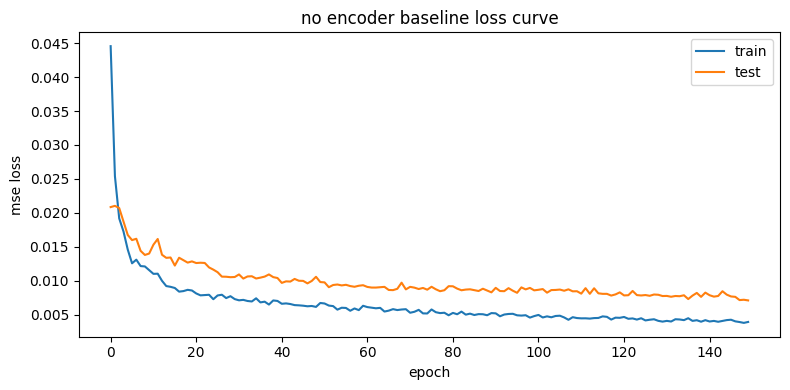

In [21]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="train")
plt.plot(test_losses, label="test")
plt.xlabel("epoch")
plt.ylabel("mse loss")
plt.title("no encoder baseline loss curve")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# generate all 34x34 pairs
all_pairs = [(i, j) for i in active_ids for j in active_ids]
all_targets = [transfer_matrix.loc[i, j] for i, j in all_pairs]

all_desc_i = torch.tensor(
    np.array([desc_scaled.loc[i].values for i, j in all_pairs]), dtype=torch.float32
).to(device)
all_desc_j = torch.tensor(
    np.array([desc_scaled.loc[j].values for i, j in all_pairs]), dtype=torch.float32
).to(device)
all_targets_tensor = torch.tensor(all_targets, dtype=torch.float32).to(device)

In [ ]:
model.eval()
with torch.no_grad():
    all_preds = model(all_desc_i, all_desc_j).cpu().numpy()

all_targets_np = np.array(all_targets)

full_mae = np.abs(all_preds - all_targets_np).mean()
full_mse = ((all_preds - all_targets_np) ** 2).mean()
print(f"full matrix mae: {full_mae:.4f}")
print(f"full matrix mse: {full_mse:.4f}")
# ok this is really interesting. the non encoder model generalizes better (stronger test set performance),
#   but it's not fitting to the train set as well as the encoder model

full matrix mae: 0.0466
full matrix mse: 0.0040


In [27]:
pred_matrix = pd.DataFrame(
    all_preds.reshape(34, 34),
    index=active_ids,
    columns=active_ids
)
pred_matrix.to_csv("no_encoder_predicted_transfer_matrix.csv")

In [29]:
no_encoder_matrix = pd.read_csv("no_encoder_predicted_transfer_matrix.csv")
no_encoder_matrix.set_index("Unnamed: 0", inplace=True)
no_encoder_matrix.index.name = None
no_encoder_matrix.index = no_encoder_matrix.index.astype(int)
no_encoder_matrix.columns = no_encoder_matrix.columns.astype(int)
no_encoder_matrix.head()

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,0.247472,0.229359,0.061232,0.063558,0.218862,0.065449,0.117259,0.184827,0.164134,0.051984,...,0.132958,0.168679,0.118727,0.273036,0.166067,0.004561,0.100947,0.160124,0.050890,0.078829
1,0.074180,0.287130,0.024224,0.032911,0.089247,0.034773,0.025694,0.117067,0.045449,0.043299,...,0.077485,0.041540,0.039043,0.140902,0.017065,0.031797,0.051239,0.103002,0.023303,0.008500
2,0.166948,0.141675,0.295710,0.073611,0.163935,0.068916,0.119261,0.170031,0.155390,0.086576,...,0.142728,0.128812,0.081920,0.192740,0.135407,0.033392,0.168192,0.109553,0.068842,0.063720
4,0.164804,0.182907,0.133407,0.270750,0.148438,0.171554,0.103389,0.150635,0.119382,0.047948,...,0.128869,0.167683,0.119842,0.237631,0.112197,0.027904,0.119330,0.188634,0.204398,0.086597
5,0.153668,0.220502,0.059987,0.075525,0.242856,0.092696,0.135654,0.126450,0.200498,0.072853,...,0.200072,0.154216,0.130375,0.298928,0.146545,0.005896,0.138272,0.173696,0.068507,0.062065


In [32]:
true_matrix = pd.read_csv("../transfer-matrix/rf_transfer_matrix.csv")
true_matrix.set_index("Unnamed: 0", inplace=True)
true_matrix.index.name = None
true_matrix.index = true_matrix.index.astype(int)
true_matrix.columns = true_matrix.columns.astype(int)
true_matrix.head()

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,0.392727,0.291660,0.127238,0.058840,0.214817,0.084705,0.149056,0.182358,0.173877,0.026375,...,0.228505,0.243433,0.149609,0.275203,0.112525,-0.011557,0.116862,0.158796,0.025454,0.029928
1,0.142172,0.395760,0.030643,0.010376,0.180707,0.064432,0.056092,0.128808,0.097788,0.039590,...,0.167477,0.032806,0.029704,0.193033,0.055264,0.066550,0.108203,0.199762,0.023240,-0.037710
2,0.196600,0.214445,0.368173,0.023968,0.207323,0.140139,0.172990,0.231019,0.156741,0.057226,...,0.197402,0.223793,0.121457,0.248807,0.134485,0.053503,-0.005610,0.253965,0.031899,0.059566
4,0.235489,0.227173,0.127394,0.410382,0.215954,0.186207,0.125068,0.196603,0.165264,0.034514,...,0.178055,0.245668,0.147579,0.284360,0.217076,-0.003941,0.037643,0.306750,0.137154,0.020968
5,0.190803,0.206530,0.097887,0.087230,0.464604,0.144950,0.159361,0.204884,0.264641,0.104493,...,0.197195,0.232923,0.117228,0.292623,0.170687,-0.020694,0.115293,0.297271,0.067951,0.051770


In [ ]:
print(kendalltau(true_matrix.values.flatten(), no_encoder_matrix.values.flatten()))
# encoder had kendall overall of 0.602

SignificanceResult(statistic=np.float64(0.563348761964679), pvalue=np.float64(5.486559670071095e-181))


In [36]:
diag_ids = active_ids

true_diag = [true_matrix.loc[i, i] for i in diag_ids]
pred_diag = [no_encoder_matrix.loc[i, i] for i in diag_ids]

true_offdiag = []
pred_offdiag = []
for i in active_ids:
    for j in active_ids:
        if i != j:
            true_offdiag.append(true_matrix.loc[i, j])
            pred_offdiag.append(no_encoder_matrix.loc[i, j])

diag_tau = kendalltau(true_diag, pred_diag)
offdiag_tau = kendalltau(true_offdiag, pred_offdiag)

print(f"diagonal kendall tau: {diag_tau.statistic:.4f}")
print(f"off diagonal kendall tau: {offdiag_tau.statistic:.4f}")

diagonal kendall tau: 0.4367
off diagonal kendall tau: 0.5430


In [ ]:
# encoder had on diag kendall 0.48 and off diag kendall of 0.58, so encoder beats out this

In [38]:
test_true = true_matrix.loc[holdout_ids, holdout_ids]
test_pred = no_encoder_matrix.loc[holdout_ids, holdout_ids]

test_tau = kendalltau(test_true.values.flatten(), test_pred.values.flatten())
print(f"test matrix kendall tau: {test_tau.statistic:.4f}")
# encoder got kendall 0.50 on test 4x4

test matrix kendall tau: 0.5500


In [ ]:
test_diag_true = [true_matrix.loc[i, i] for i in holdout_ids]
test_diag_pred = [no_encoder_matrix.loc[i, i] for i in holdout_ids]

test_offdiag_true = []
test_offdiag_pred = []
for i in holdout_ids:
    for j in holdout_ids:
        if i != j:
            test_offdiag_true.append(true_matrix.loc[i, j])
            test_offdiag_pred.append(no_encoder_matrix.loc[i, j])

test_diag_tau = kendalltau(test_diag_true, test_diag_pred)
test_offdiag_tau = kendalltau(test_offdiag_true, test_offdiag_pred)

print(f"4x4 test diag kendall tau: {test_diag_tau.statistic:.4f}")
print(f"4x4 test off diag kendall tau: {test_offdiag_tau.statistic:.4f}")
# 0 for in domain means half (2) were ordered correctly while other half were not
# exact same off diag perfromance though

4x4 test diag kendall tau: 0.0000
4x4 test off diag kendall tau: 0.2727
